# 02 — Turbofan Engine RUL Prediction

Predicting the Remaining Useful Life (RUL) of turbofan engines from the NASA C-MAPSS FD001 dataset.

Workflow: data prepared in `01_analysis.ipynb` → regression setup → baseline → candidate models → validation → hyperparameter tuning → model selection → final test evaluation → error analysis.

Companion notebooks: `01_analysis.ipynb` (EDA, preprocessing, split) and `03_classification.ipynb` (health-state classification formulation of the same problem).


## 1. Problem Definition

**Remaining Useful Life (RUL)** is the number of operational cycles an engine has left before it needs maintenance. The model takes one engine snapshot — 16 preprocessed features (operating settings + sensor channels from Notebook 01) — and predicts the RUL in cycles.

RUL prediction is useful for predictive maintenance because it lets operators plan repair *before* failure: schedule downtime, order parts, and avoid both unscheduled failures and unnecessarily conservative overhauls.

Input: one row = one engine cycle. Output: predicted RUL in cycles. As throughout this project, this is a benchmark study on simulated data, not a production maintenance system.


## 2. Dataset and Prepared Data

- **Source:** NASA C-MAPSS FD001 — simulated run-to-failure turbofan trajectories (Saxena et al., PHM 2008. One row per engine cycle; training trajectories run to failure.
- **Notebook 01 responsibilities (already done):** EDA and sensor audit → removal of invariant sensors → RUL target construction with a piecewise-linear cap at 125 cycles → engine-level 80/20 train/validation split → scaling (fitted on train only) → export to `data/processed/`.
- **Notebook 02 responsibilities (this notebook):** regression modeling → validation → model comparison → tuning → selection → final test evaluation.

**Target:** `RUL = min(max_cycle − cycle, 125)` for training rows. For the test engines, the true RUL at the last observed cycle is taken from `RUL_FD001.txt` — test RULs range 7–145, so 11 of the 100 test engines exceed the training cap of 125 (relevant for the error analysis in Section 14).

**Features:** 16 standardized columns — `os_1`, `os_2`, and 14 sensor channels (`sensor_2`, `sensor_3`, `sensor_4`, `sensor_7`–`sensor_9`, `sensor_11`–`sensor_15`, `sensor_17`, `sensor_20`, `sensor_21`). `engine_id` and `cycle` are deliberately excluded: the model must learn degradation from sensor physics, not count cycles.


## 3. Regression Setup

Data prepared by Notebook 01 and consumed here unchanged:


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score,
    make_scorer,
)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV, GroupKFold

GLOBAL_SEED = 42


c:\Users\hosse\anaconda3\Lib\site-packages\sklearn\utils\_param_validation.py:14: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.2)
  from scipy.sparse import csr_matrix, issparse


In [2]:
# Prepared by 01_analysis.ipynb: engine-level split, scaler fitted on train only
X_train = pd.read_csv("data/processed/X_train.csv")
y_train = pd.read_csv("data/processed/y_train.csv").squeeze()
X_val = pd.read_csv("data/processed/X_val.csv")
y_val = pd.read_csv("data/processed/y_val.csv").squeeze()
X_test = pd.read_csv("data/processed/X_test.csv")
y_test = pd.read_csv("data/processed/y_test.csv").squeeze()

# Engine ID of every training row (groups for GroupKFold during tuning)
train_engine_ids = pd.read_csv("data/processed/train_engine_ids.csv").squeeze()

assert X_train.columns.tolist() == X_val.columns.tolist() == X_test.columns.tolist()
assert len(X_train) == len(y_train) == len(train_engine_ids)
assert len(X_val) == len(y_val) and len(X_test) == len(y_test)
assert X_train.isna().sum().sum() == X_val.isna().sum().sum() == X_test.isna().sum().sum() == 0

X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape


((16561, 16), (16561,), (4070, 16), (4070,), (100, 16), (100,))

| Split | Engines | Rows | Purpose |
|---|---|---|---|
| Train | 80 | 16,561 | Fitting and hyperparameter tuning |
| Validation | 20 | 4,070 | Model comparison and selection |
| Test | 100 (different engines) | 100 (last observation each) | Final evaluation only |

The validation set is used for **all** model comparison and selection; the test set is reserved for a single final evaluation after the model is chosen (Section 11). The split is **engine-level** — no engine appears in more than one split — so the model is evaluated on engines it has never seen.


## 4. Evaluation Metrics

| Metric | Meaning | Role here |
|---|---|---|
| **MAE** (↓) | Average absolute error in cycles | Easy-to-read typical error |
| **RMSE** (↓) | Root mean squared error — penalizes large errors | Sensitive to occasional big misses |
| **R²** (↑) | Variance explained relative to predicting the mean | Overall fit quality |
| **NASA score** (↓) | Asymmetric PHM'08 score; late errors punished harder than early ones | Challenge metric |

The NASA score is the C-MAPSS/PHM'08 evaluation function. With error d = predicted − actual it applies `exp(−d/13) − 1` for early predictions (d < 0) and `exp(d/10) − 1` for late predictions (d ≥ 0). A *late* prediction (overestimating remaining life) is riskier operationally than an early one, and the score encodes that asymmetry. We report the per-engine mean; the conventional challenge score is the sum over engines (×100 here).


In [3]:
def nasa_score(y_true, y_pred):
    error = y_pred - y_true
    score = np.where(
        error < 0,
        np.exp(-error / 13) - 1,
        np.exp(error / 10) - 1,
    )
    return np.sum(score) / len(y_pred)


def evaluate_model(y_true, y_pred, model_name):
    return pd.DataFrame([{
        "Model": model_name,
        "↓MAE": mean_absolute_error(y_true, y_pred),
        "↓RMSE": root_mean_squared_error(y_true, y_pred),
        "↑R2": r2_score(y_true, y_pred),
        "↓NASA": nasa_score(y_true, y_pred),
    }]).round(2)


## 5. Baseline Model

**Linear Regression** on the standardized features. A simple baseline matters: if the ensemble models cannot clearly beat it, their added complexity is not justified by the data.

On this feature set the linear model is a deliberately weak reference — the piecewise-linear RUL target and nonlinear sensor degradation are hard for a purely linear fit — but it establishes the point all candidates must beat.


In [4]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_val)

lr_score = evaluate_model(y_val, y_pred_lr, "Linear Regression")
lr_score


,Model,↓MAE,↓RMSE,↑R2,↓NASA
0,Linear Regression,16.51,20.43,0.76,7.09


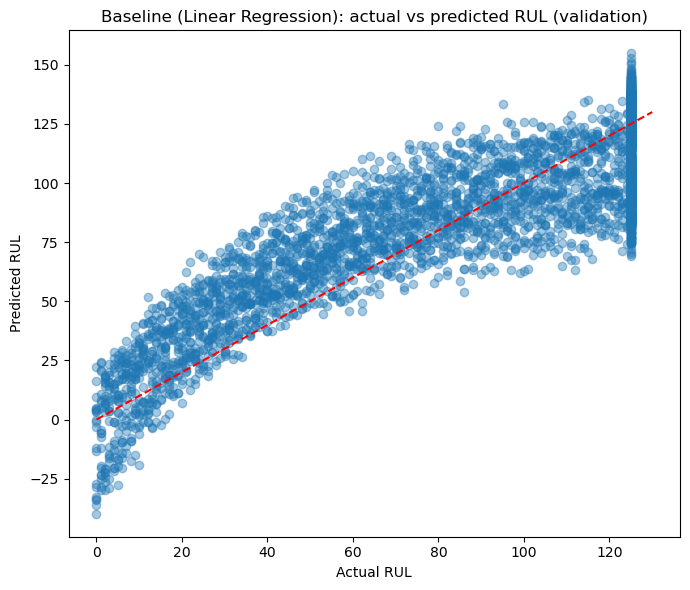

In [21]:
plt.figure(figsize=(7, 6))
plt.scatter(y_val, y_pred_lr, alpha=0.4)
lims = [0, 130]
plt.plot(lims, lims, "--", color="red", linewidth=1.5)
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Baseline (Linear Regression): actual vs predicted RUL (validation)")
plt.tight_layout()
plt.show()


The linear model cannot reproduce the nonlinear, saturating RUL profile: predictions for engines in the mid-life band (actual RUL 31–60) are on average ~19 cycles too high, and errors stay large across the whole range — exactly the behavior the ensemble models are expected to fix.


## 6. Candidate Models

Four candidates are evaluated (no new model families are added):

- **Random Forest** — bagged trees; a robust default for tabular data with low sensitivity to hyperparameters.
- **Gradient Boosting** — sequential shallow trees fitted on residuals; typically strong on low-dimensional sensor data.
- **XGBoost** — regularized gradient boosting; usually the strongest tabular candidate in practice.
- **SVR (RBF kernel)** — a non-tree nonlinear regressor, kept from the original notebook for family diversity.

All models are fitted on the training split only and evaluated on the validation split, with the notebook's original initial hyperparameters unchanged.


In [6]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=GLOBAL_SEED, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_val)

gb_model = GradientBoostingRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=3, random_state=GLOBAL_SEED,
)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_val)

xgb_model = XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=GLOBAL_SEED, n_jobs=-1,
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_val)

svr_model = SVR(kernel="rbf")
svr_model.fit(X_train, y_train)
y_pred_svr = svr_model.predict(X_val)


## 7. Validation Strategy

- **Model comparison** uses the 20-engine validation split: all rows of a validation engine stay together, so scores measure generalization to **unseen engines**, not merely unseen cycles of known engines.
- **Hyperparameter tuning** (Section 9) uses `GroupKFold(n_splits=3)` inside the training split, grouped by engine ID: each engine's rows stay within one fold, so no tuning fold is ever scored on engines it trained on.

Rows from the same engine are strongly correlated — they are snapshots of one degradation trajectory. The grouping prevents that correlation from inflating scores; it does **not** impose temporal ordering within a trajectory, which is acceptable here because every row is a single-snapshot prediction task.


## 8. Initial Model Results

All five models on the validation split (sorted by NASA score):


In [7]:
initial_results = (
    pd.concat([
        lr_score,
        evaluate_model(y_val, y_pred_rf, "Random Forest"),
        evaluate_model(y_val, y_pred_gb, "Gradient Boosting"),
        evaluate_model(y_val, y_pred_xgb, "XGBoost"),
        evaluate_model(y_val, y_pred_svr, "SVR"),
    ], ignore_index=True)
    .sort_values("↓NASA")
    .reset_index(drop=True)
)

initial_results


,Model,↓MAE,↓RMSE,↑R2,↓NASA
0,Linear Regression,16.51,20.43,0.76,7.09
1,Gradient Boosting,12.54,17.06,0.83,7.23
2,Random Forest,12.56,17.21,0.83,7.96
3,XGBoost,12.18,16.97,0.83,8.37
4,SVR,12.19,17.49,0.82,10.92


Every ensemble beats the linear baseline by a wide margin (MAE ~12.2 vs 16.5; R² 0.82–0.83 vs 0.76), confirming the RUL–sensor relationship is nonlinear.

The metrics genuinely disagree, which is why all four are kept visible:

- **XGBoost** leads on MAE (12.18) and RMSE (16.97) but ranks *fourth* on the NASA score.
- **Gradient Boosting** has the best NASA score of the ensembles (7.23) but a slightly worse MAE than XGBoost.
- **SVR** matches the ensembles on MAE (12.19) yet has by far the worst NASA score (10.92).

Why the flip? The NASA score is dominated by the largest *late* errors (over-predictions), which its exponential term punishes much harder than MAE does:


In [8]:
rows = []
for name, y_pred in [
    ("Linear Regression", y_pred_lr),
    ("Random Forest", y_pred_rf),
    ("Gradient Boosting", y_pred_gb),
    ("XGBoost", y_pred_xgb),
    ("SVR", y_pred_svr),
]:
    err = y_pred - y_val.values
    per_engine = np.where(err < 0, np.exp(-err / 13) - 1, np.exp(err / 10) - 1)
    rows.append({
        "Model": name,
        "late (d>0)": per_engine[err > 0].sum() / len(err),
        "early (d<=0)": per_engine[err <= 0].sum() / len(err),
        "total NASA": per_engine.mean(),
    })

pd.DataFrame(rows).round(2)


,Model,late (d>0),early (d<=0),total NASA
0,Linear Regression,4.37,2.73,7.09
1,Random Forest,6.36,1.60,7.96
2,Gradient Boosting,5.86,1.37,7.23
3,XGBoost,6.98,1.39,8.37
4,SVR,9.96,0.96,10.92


The ensembles are the *most accurate* models (low early-error contribution, 1.4–1.6), but their remaining late errors dominate their NASA totals (5.9–7.0 of ~7–8). SVR's late-error contribution (9.96) explains its poor NASA score despite a competitive MAE, and the linear baseline's more symmetric error profile explains why it ranks well on NASA while being clearly the weakest model overall.


**Which sensors drive the predictions?** Feature importance for the three tree models (importances are not defined for Linear Regression and SVR):


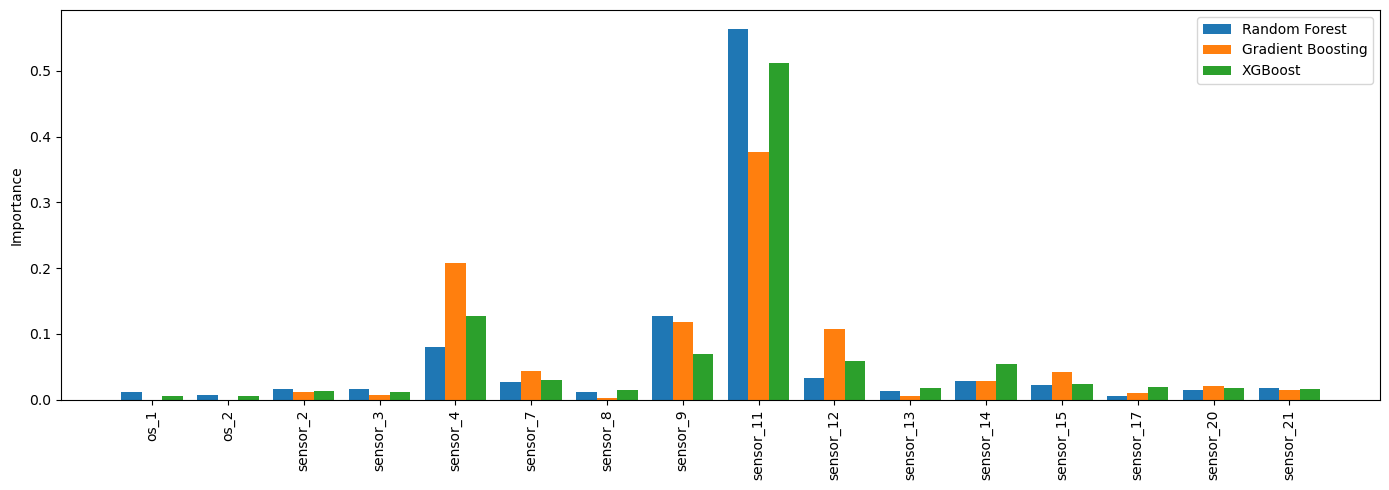

In [9]:
x = np.arange(len(X_train.columns))
width = 0.27

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width, rf_model.feature_importances_, width, label="Random Forest")
ax.bar(x, gb_model.feature_importances_, width, label="Gradient Boosting")
ax.bar(x + width, xgb_model.feature_importances_, width, label="XGBoost")

ax.set_xticks(x)
ax.set_xticklabels(X_train.columns, rotation=90)
ax.set_ylabel("Importance")
ax.legend()
plt.tight_layout()
plt.show()


All three tree models agree: `sensor_11` dominates, followed by `sensor_4`, `sensor_9` and `sensor_12`. Per the C-MAPSS output table in the paper, `sensor_11` is the static pressure at the HPC outlet (Ps30) and `sensor_4` the total temperature at the LPT outlet (T50) — gas-path channels directly downstream of the simulated HPC degradation module, so their dominance is physically consistent with the data-generating process.


## 9. Hyperparameter Tuning

`RandomizedSearchCV` (20 candidates, fixed seed) per model, scored by the **NASA score** (lower is better) with the engine-grouped `GroupKFold(3)` from Section 7. The validation set is not used during tuning. Search spaces are the notebook's originals, unchanged in scope; randomized search suits them because the spaces are large (10³–10⁴ combinations) and the budget is deliberately small.


In [10]:
nasa_scorer = make_scorer(nasa_score, greater_is_better=False)
group_kfold = GroupKFold(n_splits=3)


In [11]:
rf_param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.7, 1.0],
    "bootstrap": [True, False],
}

rf_search = RandomizedSearchCV(
    rf_model, rf_param_dist, n_iter=20, scoring=nasa_scorer,
    cv=group_kfold, random_state=GLOBAL_SEED, n_jobs=-1,
)
rf_search.fit(X_train, y_train, groups=train_engine_ids)

best_rf = rf_search.best_estimator_
y_val_pred_rf_tuned = best_rf.predict(X_val)

print("Best params:", rf_search.best_params_)
print(f"Best CV NASA score: {-rf_search.best_score_:.2f}")


Best params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 40, 'bootstrap': True}
Best CV NASA score: 13.03


In [12]:
xgb_param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6, 8],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
}

xgb_search = RandomizedSearchCV(
    xgb_model, xgb_param_dist, n_iter=20, scoring=nasa_scorer,
    cv=group_kfold, random_state=GLOBAL_SEED, n_jobs=-1,
)
xgb_search.fit(X_train, y_train, groups=train_engine_ids)

best_xgb = xgb_search.best_estimator_
y_val_pred_xgb_tuned = best_xgb.predict(X_val)

print("Best params:", xgb_search.best_params_)
print(f"Best CV NASA score: {-xgb_search.best_score_:.2f}")


Best params: {'subsample': 0.9, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Best CV NASA score: 12.22


In [13]:
gb_param_dist = {
    "n_estimators": [100, 200, 300, 400, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "subsample": [0.7, 0.8, 0.9, 1.0],
}

gb_search = RandomizedSearchCV(
    gb_model, gb_param_dist, n_iter=20, scoring=nasa_scorer,
    cv=group_kfold, random_state=GLOBAL_SEED, n_jobs=-1,
)
gb_search.fit(X_train, y_train, groups=train_engine_ids)

best_gb = gb_search.best_estimator_
y_val_pred_gb_tuned = best_gb.predict(X_val)

print("Best params:", gb_search.best_params_)
print(f"Best CV NASA score: {-gb_search.best_score_:.2f}")


Best params: {'subsample': 0.9, 'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 4, 'learning_rate': 0.01}
Best CV NASA score: 12.58


## 10. Tuned Model Results

Baselines vs tuned models on the validation split (sorted by NASA score):


In [14]:
tuned_results = (
    pd.concat([
        evaluate_model(y_val, y_pred_gb, "Gradient Boosting"),
        evaluate_model(y_val, y_val_pred_gb_tuned, "Gradient Boosting (tuned)"),
        evaluate_model(y_val, y_pred_rf, "Random Forest"),
        evaluate_model(y_val, y_val_pred_rf_tuned, "Random Forest (tuned)"),
        evaluate_model(y_val, y_pred_xgb, "XGBoost"),
        evaluate_model(y_val, y_val_pred_xgb_tuned, "XGBoost (tuned)"),
        evaluate_model(y_val, y_pred_svr, "SVR"),
    ], ignore_index=True)
    .sort_values("↓NASA")
    .reset_index(drop=True)
)

tuned_results


,Model,↓MAE,↓RMSE,↑R2,↓NASA
0,Gradient Boosting,12.54,17.06,0.83,7.23
1,Random Forest (tuned),12.37,16.85,0.84,7.34
2,XGBoost (tuned),15.22,18.28,0.81,7.40
3,Gradient Boosting (tuned),15.70,18.72,0.80,7.72
4,Random Forest,12.56,17.21,0.83,7.96
5,XGBoost,12.18,16.97,0.83,8.37
6,SVR,12.19,17.49,0.82,10.92


**Did tuning help? Only for Random Forest.**

- **Random Forest (tuned)** improved on its own baseline on every metric: NASA 7.96 → 7.34, RMSE 17.21 → 16.85, R² 0.83 → 0.84, MAE 12.56 → 12.37.
- **XGBoost (tuned)** improved the NASA score (8.37 → 7.40) but got *worse* on MAE (12.18 → 15.22), RMSE and R² — the NASA-only objective traded everyday accuracy for a better asymmetric score.
- **Gradient Boosting (tuned)** is worse than its baseline on *all four* metrics (NASA 7.23 → 7.72, MAE 12.54 → 15.70): the configuration that looked best under 3-fold CV on the training engines did not transfer to the held-out validation engines.

The honest summary: the NASA-score objective does not automatically improve overall accuracy, and only the Random Forest search found a genuinely better operating point. All results are kept as measured.


## 11. Model Selection

**Selected final model: Random Forest with the tuned hyperparameters**, based on validation results only:

- Best **RMSE** (16.85) and best **R²** (0.84) of all seven candidates, and the only model that improved on its own baseline across the board (a sign the tuning found a stable configuration, not a lucky validation draw).
- Second-best **NASA score** (7.34), behind only the untuned Gradient Boosting (7.23).
- **MAE** 12.37 — within 0.19 cycles of the best value (XGBoost 12.18).

The trade-off, stated explicitly: XGBoost remains the MAE leader, but it is clearly behind on the challenge metric (8.37 vs 7.34) and its tuning did not close that gap; untuned Gradient Boosting wins the NASA score by 0.11 but loses ~0.2 MAE, ~0.2 RMSE and 0.01 R² to the tuned forest. Random Forest (tuned) is the only candidate at or near the top of *every* column, so it is selected — not because it is the most complex model, but because no other candidate matches this balance.


## 12. Final Test Evaluation

The test set is used **only now**, after the final model has been selected — it provides the final estimate of performance on previously unseen engines.

Standard practice: refit the selected model on train + validation (all labeled data) before the single test evaluation.


In [15]:
X_final_train = pd.concat([X_train, X_val], ignore_index=True)
y_final_train = pd.concat([y_train, y_val], ignore_index=True)
print("Final training set shape:", X_final_train.shape)


Final training set shape: (20631, 16)


In [16]:
# Final model: Random Forest with the tuned hyperparameters from Section 9
final_model = RandomForestRegressor(
    **rf_search.best_params_,
    random_state=GLOBAL_SEED,
    n_jobs=-1,
)
final_model.fit(X_final_train, y_final_train)
final_test_pred = final_model.predict(X_test)

evaluate_model(y_test, final_test_pred, "Random Forest (tuned) — test")


,Model,↓MAE,↓RMSE,↑R2,↓NASA
0,Random Forest (tuned) — test,13.14,17.96,0.81,8.13


## 13. Prediction Visualization


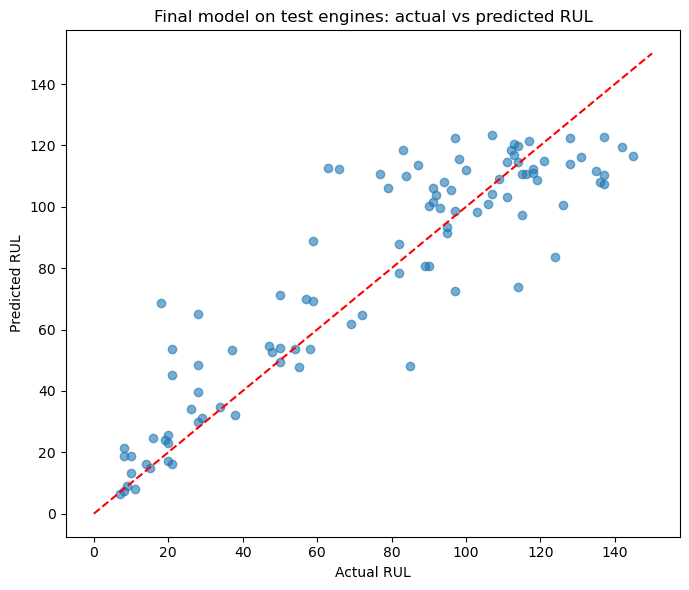

In [17]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, final_test_pred, alpha=0.6)
lims = [0, 150]
plt.plot(lims, lims, "--", color="red", linewidth=1.5)
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Final model on test engines: actual vs predicted RUL")
plt.tight_layout()
plt.show()


Predictions track actual RUL well across the range. Two visible behaviors: predictions **saturate near 125** for the healthiest engines (the training labels were capped there, so the model cannot predict beyond it), and at low actual RUL the spread widens — a few near-failure engines receive predictions of 60+ cycles, which are the largest errors in the set.


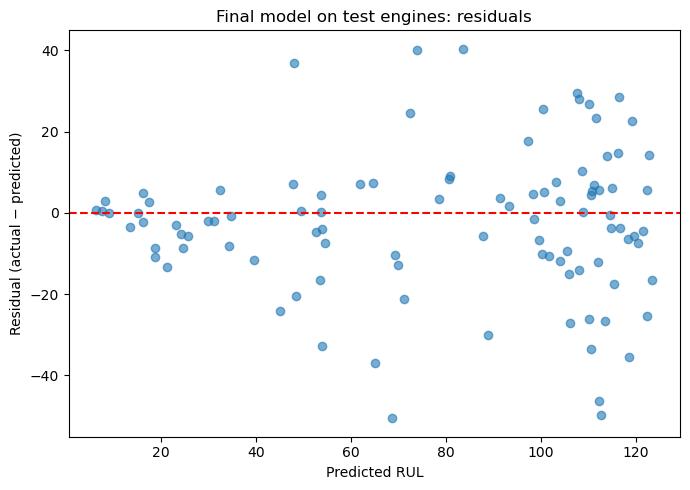

In [18]:
residuals = y_test.values - final_test_pred  # positive = model under-predicted (early)

plt.figure(figsize=(7, 5))
plt.scatter(final_test_pred, residuals, alpha=0.6)
plt.axhline(0, linestyle="--", color="red", linewidth=1.5)
plt.xlabel("Predicted RUL")
plt.ylabel("Residual (actual − predicted)")
plt.title("Final model on test engines: residuals")
plt.tight_layout()
plt.show()


The residual cloud is centered slightly below zero (mean −2.7 cycles: the model is mildly optimistic on average) with a standard deviation of ~17.8 cycles. There is no strong funnel pattern; the largest misses (±40–50 cycles) sit at mid-range predicted values rather than at one end of the scale.


## 14. Error Analysis

How errors are distributed across the RUL range, and which engines are missed:


In [19]:
residuals = pd.Series(y_test.values - final_test_pred, index=y_test.index)  # actual - predicted
abs_err = residuals.abs()

bands = pd.cut(
    y_test,
    bins=[0, 30, 60, 100, 150],
    labels=["RUL <= 30", "31-60", "61-100", "> 100"],
)

error_by_band = pd.DataFrame({
    "engines": y_test.groupby(bands, observed=True).size(),
    "MAE": abs_err.groupby(bands, observed=True).mean().round(2),
    "mean residual": residuals.groupby(bands, observed=True).mean().round(2),
})

error_by_band


,engines,MAE,mean residual
RUL,,,
RUL <= 30,25,10.45,-9.52
31-60,14,8.99,-6.41
61-100,28,17.42,-10.11
> 100,33,13.31,10.35


- **The hardest region is mid-life (61–100, MAE ≈ 17.4), not the approach to failure** (≤30, MAE ≈ 10.4). Close to failure the sensors carry a strong degradation signal; in the 61–100 band the degradation is only weakly visible, which is exactly where the RUL–sensor relationship is hardest to pin down.
- **The bias flips sign across the range:** below the cap the model over-predicts (mean residual ≈ −10, optimistic — the "late" direction the NASA score penalizes), while in the >100 band it under-predicts by ≈ +10 because predictions are clipped near 125.
- The clip is a property of the **target definition, not the model**: 11 test engines have true RUL above the 125-cycle training cap, and on those engines the MAE rises to ≈ 21.2.


In [20]:
worst = pd.DataFrame({
    "engine": y_test.index + 1,
    "actual": y_test.values,
    "predicted": final_test_pred.round(1),
    "residual": residuals.round(1),
}).sort_values("residual", key=abs, ascending=False).head(5)

worst


,engine,actual,predicted,residual
40,41,18,68.6,-50.6
78,79,63,112.8,-49.8
26,27,66,112.3,-46.3
11,12,124,83.6,40.4
44,45,114,73.9,40.1


The five largest misses are single engines in the 18–124 actual-RUL range with errors of 40–50 cycles — three of them over-predictions (optimistic, e.g. engine 41 predicted at 68.6 with 18 cycles actually remaining). With only 100 test engines, individual cases like these move the headline metrics noticeably.


## 15. Limitations

- **Simulated data.** C-MAPSS trajectories come from a thermodynamic simulation with imposed degradation and noise; nothing here should be read as real-world aircraft-engine performance.
- **Small test set.** 100 engines: the test metrics carry noticeable statistical uncertainty, and single engines move MAE by ~0.5–1.0 cycles.
- **RUL cap.** Training labels saturate at 125 cycles, so the model cannot distinguish "150 cycles left" from "200 cycles left" — 11 test engines sit beyond the cap (Section 14).
- **Single scenario.** FD001 covers one operating condition and one unspecified HPC degradation mode; nothing is established for other subsets or fault modes.
- **Snapshot features.** The model sees one cycle at a time, with no memory of the trajectory; rolling or sequence features could capture degradation trends a single snapshot cannot.
- **Statistical model, not physics.** The regressor learns statistical associations in the simulated data; it does not represent a physical degradation model.


## 16. Conclusion

- Built a leakage-controlled RUL regression pipeline on C-MAPSS FD001: a linear baseline, three tree ensembles and SVR, NASA-score-optimized tuning with engine-grouped CV, and a single final test evaluation.
- **Selected model:** Random Forest with tuned hyperparameters — the only model whose tuning improved every validation metric (NASA 7.96 → 7.34, R² 0.84, RMSE 16.85) — refit on train + validation.
- **Test performance:** MAE 13.14, RMSE 17.96, R² 0.81, NASA 8.13 — consistent with validation (MAE 12.37, NASA 7.34), with the expected gap from the small 100-engine test set.
- Errors are largest in the mid-life band (61–100) and asymmetric: over-prediction below the 125-cycle cap, under-prediction above it.
- Main limitation: simulated, single-scenario data with capped labels. Future work: temporal features (rolling statistics over recent cycles), a balanced tuning objective that does not sacrifice MAE for the NASA score, and evaluation on the other C-MAPSS subsets.
